  0%|          | 0/23 [00:00<?, ?it/s]

XJTU_2C_battery-7.pkl
[0, 1]
2.0 1.938
time of cycle 1 if strictly increasing
time of cycle 2, The following positions are not in ascending order.：
arr[2929]=10209.360000000554 -> arr[2930]=10208.940000000555
time of cycle 3 if strictly increasing
time of cycle 4 if strictly increasing
time of cycle 5 if strictly increasing
time of cycle 6, The following positions are not in ascending order.：
arr[2921]=38630.94000000271 -> arr[2922]=38630.700000002704
time of cycle 7 if strictly increasing
time of cycle 8 if strictly increasing
time of cycle 9 if strictly increasing
time of cycle 10 if strictly increasing
time of cycle 11 if strictly increasing
time of cycle 12 if strictly increasing
time of cycle 13 if strictly increasing
time of cycle 14, The following positions are not in ascending order.：
arr[6945]=100057.14000000752 -> arr[6946]=100056.84000000752
time of cycle 15 if strictly increasing
time of cycle 16 if strictly increasing
time of cycle 17 if strictly increasing
time of cycle 1

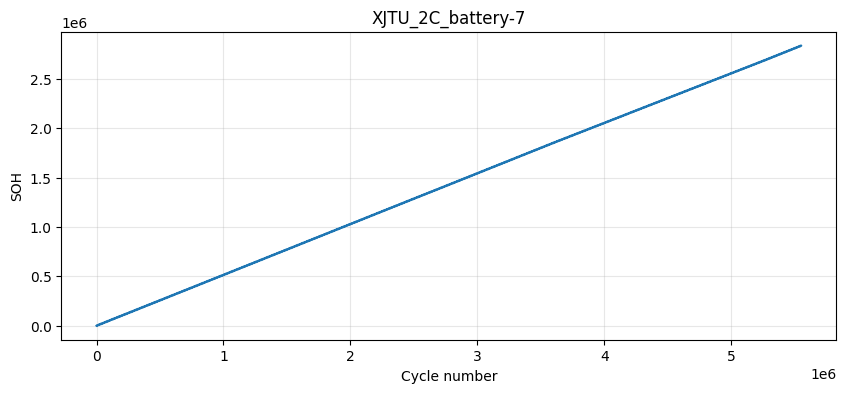

  4%|▍         | 1/23 [00:03<01:08,  3.13s/it]

XJTU_2C_battery-2.pkl
[0, 1]
2.0 1.861
time of cycle 1 if strictly increasing
time of cycle 2 if strictly increasing
time of cycle 3 if strictly increasing
time of cycle 4, The following positions are not in ascending order.：
arr[6766]=27975.160000002157 -> arr[6767]=27974.50000000216
time of cycle 5 if strictly increasing
time of cycle 6 if strictly increasing
time of cycle 7, The following positions are not in ascending order.：
arr[6474]=48538.64000000355 -> arr[6475]=48537.92000000355
time of cycle 8, The following positions are not in ascending order.：
arr[3148]=52074.92000000363 -> arr[3149]=52074.38000000363
time of cycle 9 if strictly increasing
time of cycle 10, The following positions are not in ascending order.：
arr[2871]=65694.72000000466 -> arr[2872]=65694.18000000465
time of cycle 11 if strictly increasing
time of cycle 12 if strictly increasing
time of cycle 13, The following positions are not in ascending order.：
arr[6812]=90637.14000000658 -> arr[6813]=90636.60000000658

  4%|▍         | 1/23 [00:06<02:12,  6.03s/it]


KeyboardInterrupt: 

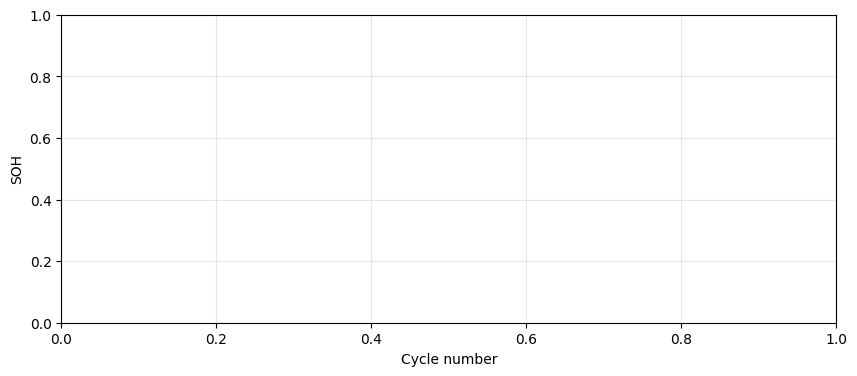

In [3]:
import os
import pickle
import pandas as pd
from openpyxl.styles.builtins import total
from sympy.physics.units import charge
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import json
import seaborn as sns
from scipy.interpolate import PchipInterpolator
from pathlib import Path
from scipy.interpolate import splrep, splev
from scipy import interpolate
import matplotlib.pyplot as plt

from sympy.physics.control.control_plots import matplotlib

path = '/data/trf/python_works/BatteryLife/dataset/XJTU/'
ppath = Path(path)
files = os.listdir(path)
files = [i for i in files if i.endswith('.pkl')]
soc = []
cell = []
life_label = []
file_name = []
total_soh = []
total_cycles = []
data = {}
for file in tqdm(files):
    print(file)
    file_name.append(file)
    with open(path + f'{file}', 'rb') as f:
        cell_data = pickle.load(f)
        filename = file.split('.pkl')[0]
        length = len(cell_data['cycle_data'])
        cell = cell_data['cycle_data']
        nominal_capacity = cell_data['nominal_capacity_in_Ah']


        df = pd.DataFrame()
        SOC_interval = cell_data['SOC_interval']  # get the charge and discharge soc interval
        print(SOC_interval)

        SOC_interval = SOC_interval[1] - SOC_interval[0]


        times = []
        cycles = []
        for i in range(0, length):
            cycle_df = pd.DataFrame()
            cycle_data_len = len(cell_data['cycle_data'][i])
            cycle_data = cell_data['cycle_data'][i]
            cycle_df['current'] = cycle_data['current_in_A']
            cycle_df['voltage'] = cycle_data['voltage_in_V']
            cycle_df['charge_capacity'] = cycle_data['charge_capacity_in_Ah']
            cycle_df['discharge_capacity'] = cycle_data['discharge_capacity_in_Ah']
            cycle_df['test_time_s'] = cycle_data['time_in_s']
            cycle_df['cycle_number'] = cycle_data['cycle_number']
            cycles.append(i+1)

            if file.startswith('CALB_-10'):
                soh_value = abs(cycle_df.loc[cycle_df['current'] < 0, 'discharge_capacity'].min())
            elif 'DefaultGroup' in file:
                soh_value = float(cycle_df['discharge_capacity'].max())
            else:
                soh_value = float(cycle_df.loc[cycle_df['current'] < 0, 'discharge_capacity'].max())


            if SOC_interval == 0:
                SOC_interval = 1

            if i == 0:
                print(nominal_capacity, max(cycle_df['discharge_capacity']))

            time = cycle_df['test_time_s'].tolist()
            diff = np.diff(time)

            bad_idx = np.where(diff < 0)[0]

            if len(bad_idx) == 0:
                print(f"time of cycle {i+1} if strictly increasing")
            else:
                print(f"time of cycle {i+1}, The following positions are not in ascending order.：")
                for i in bad_idx:
                    print(f"arr[{i}]={time[i]} -> arr[{i + 1}]={time[i + 1]}")
            times += time

            times += cycle_df['test_time_s'].tolist()


        fig = plt.figure(figsize=(10, 4))
        plt.xlabel('Cycle number')
        plt.ylabel('SOH')
        plt.grid(alpha=.3)
        plt.plot(range(len(times)), times)
        plt.title(f'{filename}')
        plt.show()

